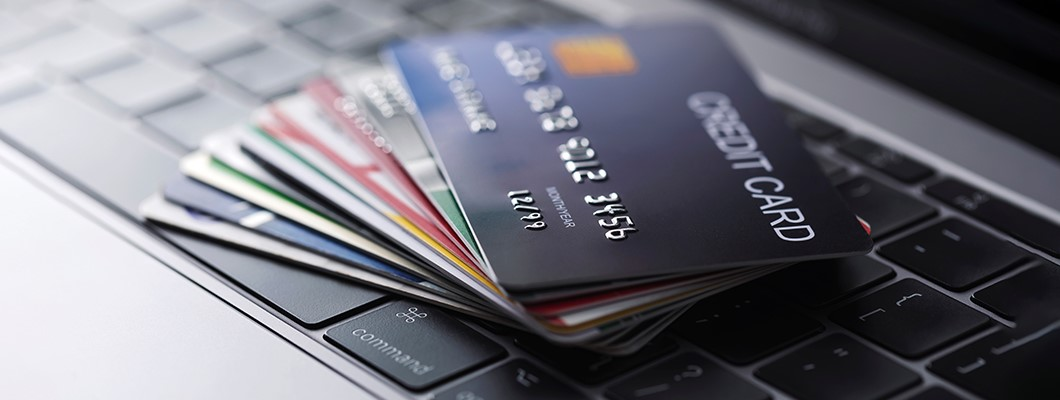

# **Credit Card Approval Case Study**

## **Business Context**

Credit scoring is an important part of the financial industry, particularly as a measure of assessing the risk associated with issuing credit cards. By analyzing the data submitted by applicants, banks can estimate the chances of future defaults on credit card payments. Based on their analysis of the financial and personal attributes of the applicants, banks make informed decisions on whether to issue a credit card to an applicant. This allows for effective risk management.

Traditionally, banks undertook the task of determining creditworthiness manually via a structured process. This would include reviewing the applicant's credit report to assess their credit history, evaluating employment status and income statistics to assess their ability to repay, and also considering other factors such as length of credit history and types and number of credit accounts. This manual process would be time-consuming, even considering the initial screening part only.


## **Learning Objective**

A renowned bank has been facing a challenge: the percentage of credit card customers who defaulted payments has increased from 5% to 9%. This required them to thoroughly review the existing application screening process. Based on the results of the same, they believe that one of the reasons for the increase in defaulters is a lapse in process adherence. This might have been due to a rise in the volume of credit card applications, which is up by 35% in the past three months.

To accurately assess the risk involved and approve credit to financially reliable applicants, the bank wants to introduce a machine learning-based solution.

**The objectives are to:**

- Analyze the data of past applicants.
- Identify patterns in the data.
- Build an ML model to accurately determine applicants' credibility.
- Identify the attributes that drive eligibility for availing credit cards.
- Streamline the initial screening process.
- Efficiently and accurately assess the creditworthiness of applications.

#### **Importing the necessary packages**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Display all columns of the dataset
pd.set_option("display.max_columns", None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

#### **Load the Credit Card Approval Dataset**

In [2]:
# Load the dataset
path = r"https://raw.githubusercontent.com/MonishDY/AI-Track/refs/heads/main/Module%203%20-%20Machine%20Learning/Assignment%201/Credit%20Card%20Approval%20Dataset.csv"
df = pd.read_csv(path)

#### **Data Overview**

The initial steps to understand any dataset is to:

- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

In [3]:
# Display the first five rows
df.head()

,Age,Credit Score,Annual Income,PriorDefault,Employed,Approval,Gender
0,33.541537,678.0,53.984881,0,1,No,Male
1,24.808335,624.0,41.131160,1,0,No,Male
2,23.342078,671.0,33.012298,1,1,No,Female
3,29.987970,671.0,66.942232,1,1,No,Female
4,29.707443,630.0,116.613468,1,1,No,Male


In [4]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display the column names
print("\nColumn Names:")
for i, column in enumerate(df.columns.tolist()):
  print(f"{i+1}. {column}")

Dataset Shape: (2500, 7)

Column Names:
1. Age
2. Credit Score
3. Annual Income
4. PriorDefault
5. Employed
6. Approval
7. Gender


In [5]:
# Display info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            2500 non-null   float64
 1   Credit Score   2500 non-null   float64
 2   Annual Income  2500 non-null   float64
 3   PriorDefault   2500 non-null   int64  
 4   Employed       2500 non-null   int64  
 5   Approval       2500 non-null   object 
 6   Gender         2500 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 136.8+ KB


In [6]:
# Statistical Summary
df.describe()

,Age,Credit Score,Annual Income,PriorDefault,Employed
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,37.014342,703.019600,76.421887,0.300000,0.702000
std,9.814617,60.102094,32.942672,0.458349,0.457471
min,16.400000,342.000000,4.870000,0.000000,0.000000
25%,29.788468,666.000000,51.732313,0.000000,0.000000
50%,35.487664,713.000000,71.695510,0.000000,1.000000
75%,42.573775,747.000000,97.244651,1.000000,1.000000
max,78.200000,837.000000,204.400000,1.000000,1.000000


#### **Data Cleaning**

In [7]:
# Check the number of missing values in each column
print("Missing Values:")
print(df.isnull().sum())

# Check the number of duplicate rows
print("\nNumber of Duplicate Rows:", df.duplicated().sum())

Missing Values:
Age              0
Credit Score     0
Annual Income    0
PriorDefault     0
Employed         0
Approval         0
Gender           0
dtype: int64

Number of Duplicate Rows: 0



Approval Percentage:
Approval
Yes    56.04
No     43.96
Name: proportion, dtype: float64


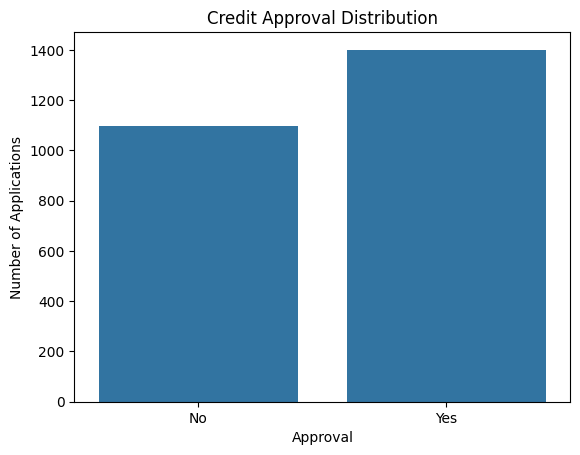

In [8]:
# Display the distribution as percentages
print("\nApproval Percentage:")
print(df["Approval"].value_counts(normalize=True) * 100)

# Visualize the target variable distribution
sns.countplot(data=df, x="Approval")

# Add chart title and labels
plt.title("Credit Approval Distribution")
plt.xlabel("Approval")
plt.ylabel("Number of Applications")

# Display the plot
plt.show()

#### **Feature Engineering and Encoding**

In [9]:
# Check the unique categories present in Gender
print("Gender Categories:")
print(df["Gender"].unique())

# Convert Gender into one-hot encoded columns
df = pd.get_dummies(
    df,
    columns=["Gender"],
    drop_first=True,
    dtype=int
)

Gender Categories:
['Male' 'Female' 'Others']


In [10]:
# Encode the target variable
df["Approval"] = df["Approval"].map({
    "No": 0,
    "Yes": 1
})

# Display the first five rows
df.head()

,Age,Credit Score,Annual Income,PriorDefault,Employed,Approval,Gender_Male,Gender_Others
0,33.541537,678.0,53.984881,0,1,0,1,0
1,24.808335,624.0,41.131160,1,0,0,1,0
2,23.342078,671.0,33.012298,1,1,0,0,0
3,29.987970,671.0,66.942232,1,1,0,0,0
4,29.707443,630.0,116.613468,1,1,0,1,0


In [11]:
# Separate the features from the target variable
X = df.drop("Approval", axis=1)

# Store Approval as the target variable
y = df["Approval"]

# Display the shapes of X and y
print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (2500, 7)
y Shape: (2500,)


#### **Train-Test Split**

In [12]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shape of each dataset
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (2000, 7)
Testing Features: (500, 7)
Training Target: (2000,)
Testing Target: (500,)


#### **Scaling**

In [13]:
# Create the StandardScaler object
scaler = StandardScaler()

# Fit the scaler
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### **Model Training and Evaluation**

**i. Logistic Regression**

In [14]:
# Logistic Regression model
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [15]:
# Predict the approval status for the test data
y_pred_lr = logistic_model.predict(X_test_scaled)

In [16]:
# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy (%):", lr_accuracy * 100)

Logistic Regression Accuracy (%): 82.19999999999999


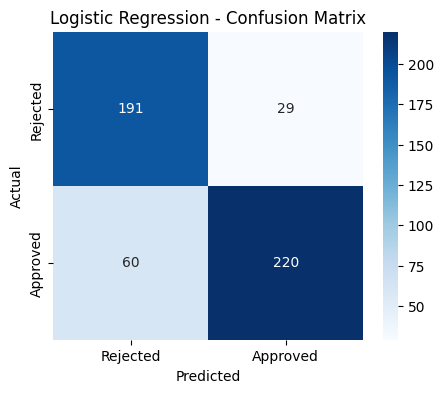

In [17]:
# Generate the confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Display the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ii. Support Vector Machine**

In [18]:
# SVM model
svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [19]:
# Predict the approval status for the test data
y_pred_svm = svm_model.predict(X_test_scaled)

In [20]:
# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy (%):", svm_accuracy * 100)

SVM Accuracy (%): 82.19999999999999


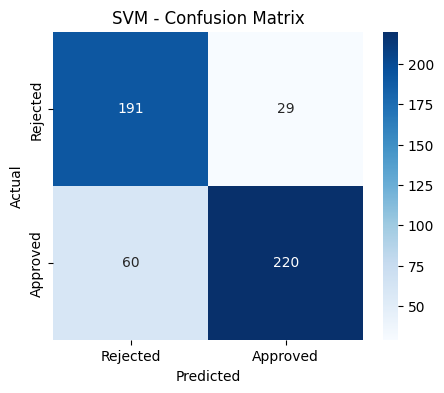

In [21]:
# Generate the confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Display the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**iii. Decision Tree**

In [22]:
# Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=42
)
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=10,
                       random_state=42)

In [23]:
# Predict the approval status for the test data
y_pred_dt = decision_tree_model.predict(X_test)

In [24]:
# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy (%):", dt_accuracy * 100)

Decision Tree Accuracy (%): 81.8


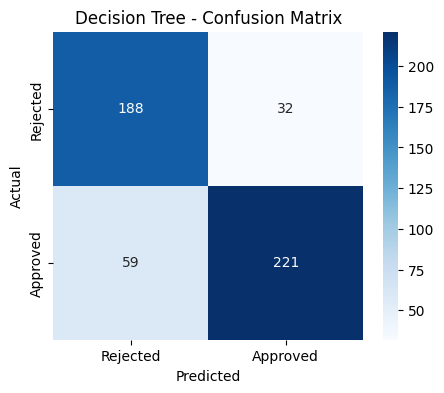

In [25]:
# Generate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Display the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**iv. Random Forest**

In [26]:
# Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    max_features="sqrt",
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42
)
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, min_samples_split=5, n_estimators=500,
                       random_state=42)

In [27]:
# Predict the approval status for the test data
y_pred_rf = random_forest_model.predict(X_test)

In [28]:
# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy (%): 82.19999999999999


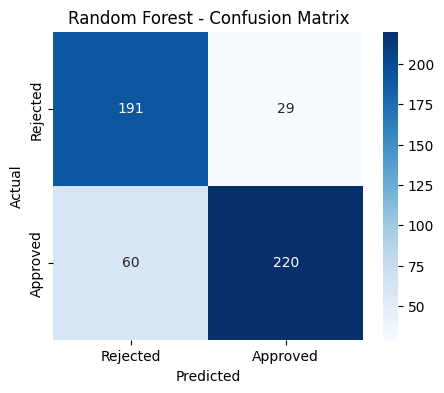

In [29]:
# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**v. K - Nearest Neighbours**

In [30]:
# KNN model
knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=10)

In [31]:
# Predict the test data
y_pred_knn = knn_model.predict(X_test_scaled)

In [32]:
# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy (%):", knn_accuracy * 100)

KNN Accuracy (%): 81.6


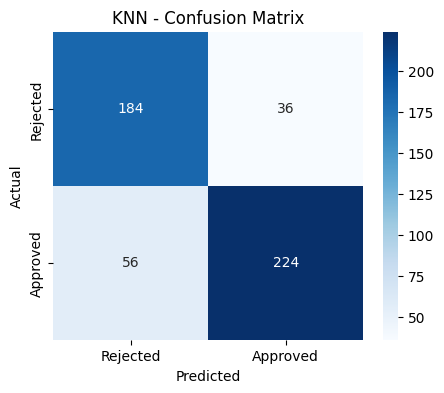

In [33]:
# Generate the confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Display the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### **Comparison of the models**

In [34]:
# Store predictions from all four models
models = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
}

# Create an empty list to store model evaluation results
results = []

# Calculate evaluation metrics for each model
for model_name, predictions in models.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions) * 100,
        "Precision": precision_score(y_test, predictions) * 100,
        "Recall": recall_score(y_test, predictions) * 100,
        "F1 Score": f1_score(y_test, predictions) * 100
    })

# Convert the results into a DataFrame
results_df = pd.DataFrame(results)

# Display the comparison table
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,82.2,88.353414,78.571429,83.175803
1,SVM,82.2,88.353414,78.571429,83.175803
2,Decision Tree,81.8,87.351779,78.928571,82.926829
3,Random Forest,82.2,88.353414,78.571429,83.175803
4,KNN,81.6,86.153846,80.000000,82.962963


#### **Custom Prediction**

In [35]:
# Create a custom applicant
custom_data = pd.DataFrame({
    "Age": [25],
    "Credit Score": [750],
    "Annual Income": [85],
    "PriorDefault": [0],
    "Employed": [1],
    "Gender": ["Male"]
})

# Encode the Gender column
custom_data = pd.get_dummies(custom_data, columns=["Gender"])
custom_data = custom_data.reindex(columns=X_train.columns, fill_value=0)

# Scale the custom data for SVM and KNN
custom_data_scaled = scaler.transform(custom_data)

# Generate predictions from all five models
pred_lr = logistic_model.predict(custom_data)
pred_svm = svm_model.predict(custom_data_scaled)
pred_dt = decision_tree_model.predict(custom_data)
pred_rf = random_forest_model.predict(custom_data)
pred_knn = knn_model.predict(custom_data_scaled)

# Store the predictions
predictions = {
    "Logistic Regression": pred_lr[0],
    "SVM": pred_svm[0],
    "Decision Tree": pred_dt[0],
    "Random Forest": pred_rf[0],
    "KNN": pred_knn[0]
}

# Convert predictions to Approved / Not Approved
for model, prediction in predictions.items():
    result = "Approved" if prediction == 1 else "Not Approved"
    print(f"{model}: {result}")

Logistic Regression: Not Approved
SVM: Approved
Decision Tree: Approved
Random Forest: Approved
KNN: Approved


In [36]:
# Count the predictions from all models
approved_count = sum(value == 1 for value in predictions.values())
not_approved_count = sum(value == 0 for value in predictions.values())

# Determine the majority prediction
final_prediction = "Approved" if approved_count > not_approved_count else "Not Approved"

# Display the results
print("Approved Predictions:", approved_count)
print("Not Approved Predictions:", not_approved_count)
print("Final Majority Prediction:", final_prediction)

Approved Predictions: 4
Not Approved Predictions: 1
Final Majority Prediction: Approved


## **Conclusion**

- This case study compared five machine learning models—Logistic Regression, SVM, Decision Tree, Random Forest, and KNN—for credit approval prediction. The models were evaluated using **accuracy, precision, recall, F1-score, confusion matrices, and overfitting analysis**.

- The results showed that the models achieved **similar overall performance**, with no single model having a significant advantage. Testing the same custom applicant across all five models also demonstrated how different models can produce different predictions.

- The developed system can help financial institutions **automate preliminary credit screening, reduce manual effort, improve consistency, and support faster decision-making**.

Overall, the case study demonstrates how machine learning can be effectively applied to **credit approval prediction and decision support**.

---

### **Case Study Completed By:** Monish D.Y. - 230701195